# **ASSIGNMENT-20: FORECASTING EXCHANGE RATES USING TIME SERIES ANALYSIS**

# **Part 1: Data Preparation and Exploration**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 1.)Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.

In [2]:
df=pd.read_csv('exchange_rate.csv',index_col='date',parse_dates=True)
df

,Ex_rate
date,
01-01-1990 00:00,0.785500
02-01-1990 00:00,0.781800
03-01-1990 00:00,0.786700
04-01-1990 00:00,0.786000
05-01-1990 00:00,0.784900
...,...
06-10-2010 00:00,0.718494
07-10-2010 00:00,0.721839
08-10-2010 00:00,0.723197


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7588 entries, 01-01-1990 00:00 to 10-10-2010 00:00
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6+ KB


# 2.)Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.

Text(0, 0.5, 'Exchange Rate')

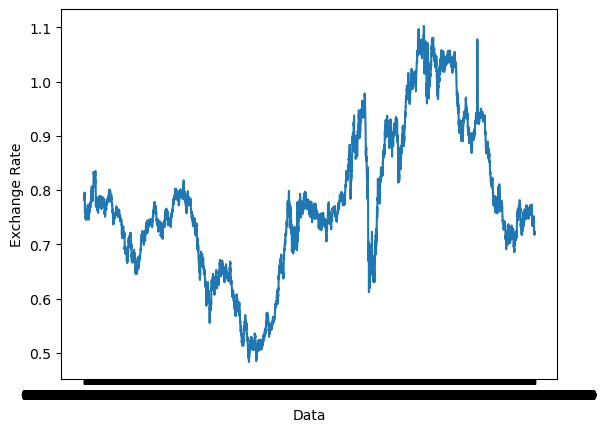

In [4]:
plt.plot(df)
plt.xlabel('Data')
plt.ylabel('Exchange Rate')

# 3.)Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.

In [5]:
# Missing Values
df.isnull().sum()

Ex_rate    0
dtype: int64

In [6]:
# Duplicates
df.duplicated().sum()

np.int64(2258)

In [7]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

# **Part 2: Model Building - ARIMA**

# 1.)Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.

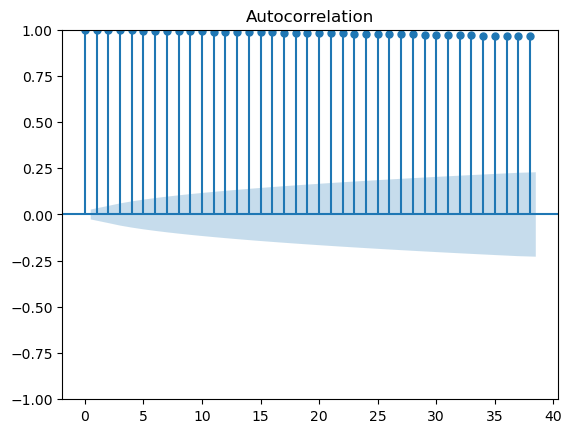

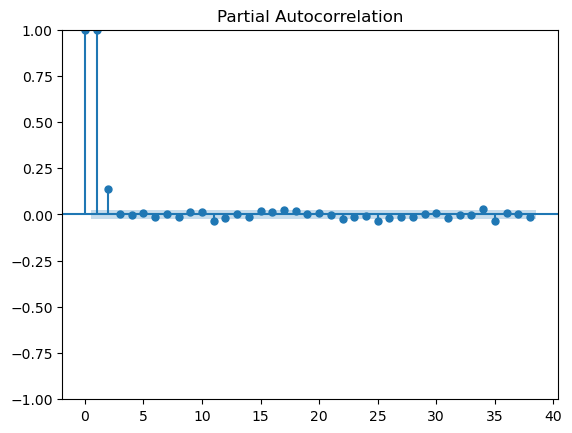

In [8]:
plot_acf(df['Ex_rate'])
plot_pacf(df['Ex_rate'])
plt.show()

# 2.)Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.

In [9]:
train_size = int(len(df)*0.8)

train = df[:train_size]
test = df[train_size:]

In [10]:
print(len(train))
print(len(test))

4264
1066


In [11]:
arima= ARIMA(train['Ex_rate'], order=(1,1,1))
arima_fit=arima.fit()
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 4264
Model:                 ARIMA(1, 1, 1)   Log Likelihood               15195.990
Date:                Sun, 15 Mar 2026   AIC                         -30385.981
Time:                        21:25:11   BIC                         -30366.908
Sample:                             0   HQIC                        -30379.242
                               - 4264                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3900      0.109     -3.577      0.000      -0.604      -0.176
ma.L1          0.3177      0.112      2.841      0.005       0.099       0.537
sigma2      4.691e-05   3.62e-07    129.724      0.0

# 3.)Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.

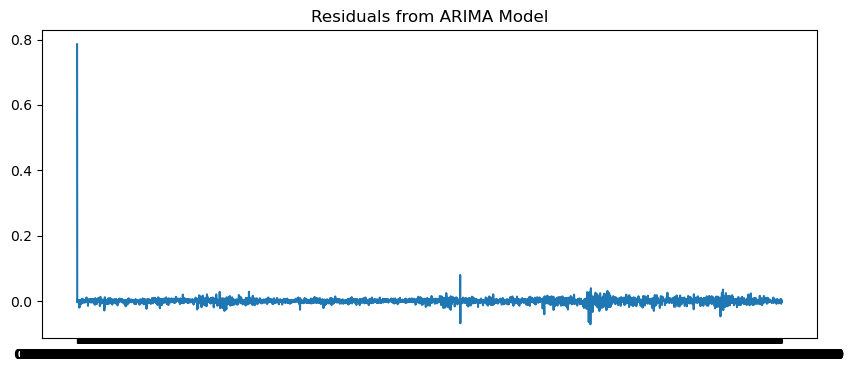

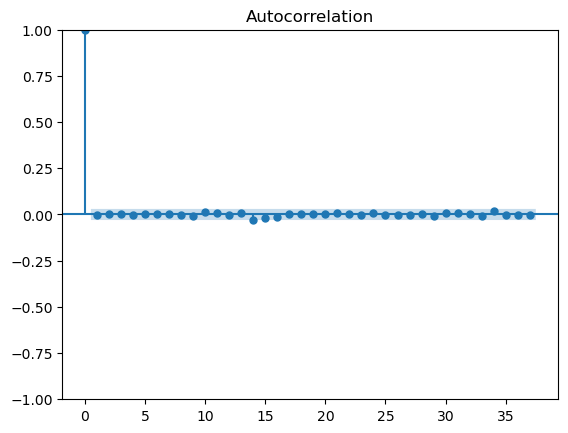

In [12]:
residuals = arima_fit.resid

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals from ARIMA Model")
plt.show()

plot_acf(residuals)
plt.show()

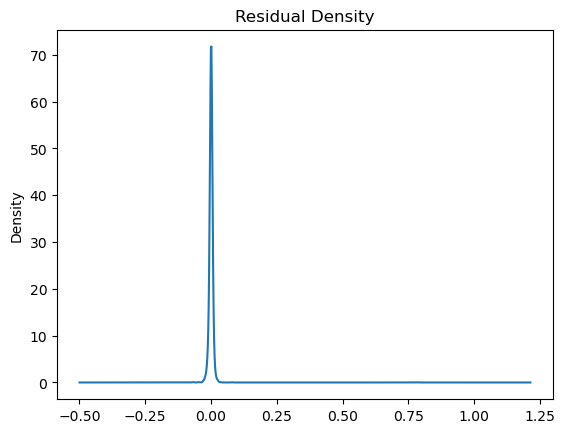

In [13]:
residuals.plot(kind='kde')
plt.title("Residual Density")
plt.show()

# 4.)Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.

In [14]:
forecast = arima_fit.forecast(steps=len(test))

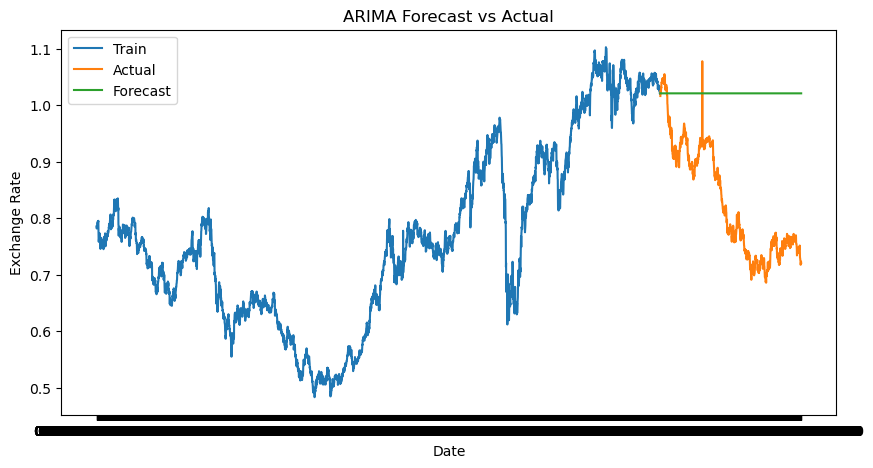

In [15]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.show()

In [16]:
mae_arima = mean_absolute_error(test['Ex_rate'], forecast)
rmse_arima = np.sqrt(mean_squared_error(test['Ex_rate'], forecast))
mape_arima = np.mean(np.abs((test['Ex_rate'].values - forecast.values) / test['Ex_rate'].values))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima)

ARIMA MAE: 0.193740517188711
ARIMA RMSE: 0.21558963480886195
ARIMA MAPE: 0.25002016741647204


# **Part 3: Model Building - Exponential Smoothing**

# 1.)Model Selection: Depending on the time series characteristics, choose an appropriate Exponential Smoothing model (Simple, Holt’s Linear, or Holt-Winters).

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 2.)Parameter Optimization: Use techniques such as grid search or AIC to find the optimal parameters for the smoothing levels and components.

In [18]:
model_exp= ExponentialSmoothing(train['Ex_rate'],trend='add',seasonal=None)
fit_exp = model_exp.fit(optimized=True)
print(fit_exp.summary())

                       ExponentialSmoothing Model Results                       
Dep. Variable:                  Ex_rate   No. Observations:                 4264
Model:             ExponentialSmoothing   SSE                              0.200
Optimized:                         True   AIC                         -42489.438
Trend:                         Additive   BIC                         -42464.006
Seasonal:                          None   AICC                        -42489.419
Seasonal Periods:                  None   Date:                 Sun, 15 Mar 2026
Box-Cox:                          False   Time:                         21:28:37
Box-Cox Coeff.:                    None                                         
                       coeff                 code              optimized      
------------------------------------------------------------------------------
smoothing_level            0.9292754                alpha                 True
smoothing_trend             0.0000

# 3.) Model Fitting and Forecasting: Fit the chosen Exponential Smoothing model and forecast future values. Compare these forecasts visually with the actual data.

In [19]:
exp_forecast = fit_exp.forecast(steps=len(test))

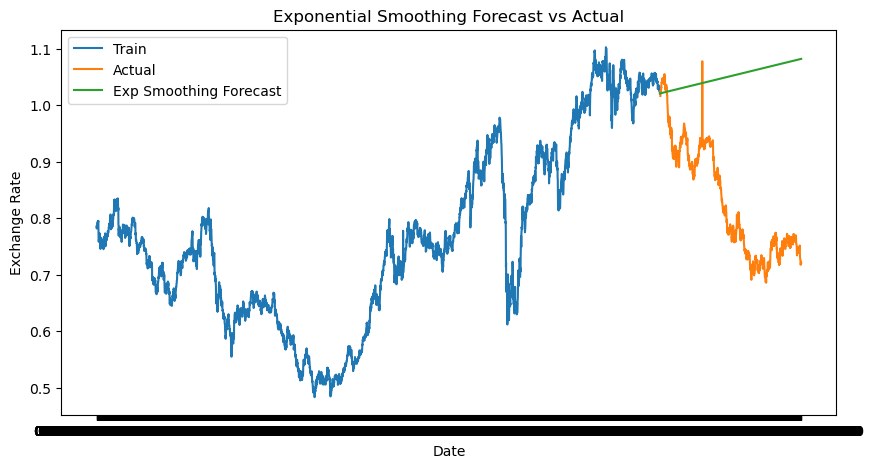

In [20]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train['Ex_rate'], label='Train')
plt.plot(test.index, test['Ex_rate'], label='Actual')
plt.plot(test.index,exp_forecast, label='Exp Smoothing Forecast')

plt.title("Exponential Smoothing Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.show()

# **Part 4: Evaluation and Comparison**

# 1.)Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.

In [21]:
mae_arima = mean_absolute_error(test['Ex_rate'], forecast)

rmse_arima = np.sqrt(mean_squared_error(test['Ex_rate'], forecast))

mape_arima =np.mean(np.abs((test['Ex_rate'].values - exp_forecast.values) / test['Ex_rate'].values))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima)

ARIMA MAE: 0.193740517188711
ARIMA RMSE: 0.21558963480886195
ARIMA MAPE: 0.2893541895137196


# 2.) Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.

**Model Comparison**

- The ARIMA model produced MAE = 0.1937, RMSE = 0.2156, and MAPE ≈ 25%, indicating moderate forecasting accuracy for the exchange rate data.
- ARIMA models are effective in capturing autocorrelation and temporal dependencies in time series data.
- However, ARIMA requires careful parameter selection (p, d, q) and assumes the series is stationary, making the modeling process more complex.
- Exponential Smoothing models are simpler and computationally efficient, and they adapt well to recent changes in the data.
- They are easier to implement compared to ARIMA but may not capture complex relationships in the time series as effectively.
- Comparing the error metrics and model behavior helps identify which model performs better for forecasting exchange rates.

# 3.) Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.

**Conclusion**
- Both ARIMA and Exponential Smoothing models were applied to forecast the USD to AUD exchange rate using historical data.
- The forecasting performance was evaluated using error metrics such as MAE, RMSE, and MAPE.
- The results indicate that the models were able to capture the general trend of the exchange rate series and produce reasonable forecasts.
- ARIMA is effective in modeling time series dependencies, while Exponential Smoothing is simpler and adapts quickly to recent changes in data.
- Based on the comparison of forecasting results and error metrics, the model with lower error values provides better prediction accuracy for this dataset.
- Overall, time series forecasting methods such as ARIMA and Exponential Smoothing are useful tools for analyzing and predicting exchange rate movements.

# --------------------------------------THE END------------------------------------------